In [1]:
import torch
import torch.nn as nn

from mslandcover.models import DeepLabV3Plus, ResNetBackbone, UNet, ResNetBackboneUNet, AttentionUNet, BYOLWrapper
from mslandcover.utils import load_pth

In [37]:
# weights_path = './weights/resnet152_202505/hires_simclr_bands3_size256_batch128_randinitfalse/resnet152/hires_simclr.pth'
weights_path = './weights/resnet101_202506/hires_byol_bands3_size256_randinitfalse/resnet101/hires_byol.pth'


backbone = ResNetBackboneUNet(in_channels=3)
weights = torch.load(weights_path, map_location='cpu')

# model = DeepLabV3Plus(
#     backbone=ResNetBackbone(
#         arch='resnet152',
#         pretrained=False,
#         out_channels=2048,
#         norm_layer=nn.BatchNorm2d,
#         dilation=True
#     ),
#     num_classes=17,
#     aux_loss=True,
#     norm_layer=nn.BatchNorm2d
# )

/tmp/ipykernel_2877661/1160375416.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(weights_path, map_location='cpu')


In [5]:
def adjust_backbone_weights(weights):
    new_weights = {}
    for key in weights.keys():
        if key.startswith('encoder.'):
            new_key = key.replace('encoder.', '')
            
            # initial layers should match up
            if new_key == 'conv1.weight':
                new_key = 'initial.0.weight'
            elif new_key == 'bn1.weight':
                new_key = 'initial.1.weight'
            elif new_key == 'bn1.bias':
                new_key = 'initial.1.bias'
            elif new_key == 'bn1.running_mean':
                new_key = 'initial.1.running_mean'
            elif new_key == 'bn1.running_var':
                new_key = 'initial.1.running_var'
            elif new_key == 'bn1.num_batches_tracked':
                new_key = 'initial.1.num_batches_tracked'
                
            new_weights[new_key] = weights[key]
        
    return new_weights

In [6]:
backbone.load_state_dict(adjust_backbone_weights(weights))

RuntimeError: Error(s) in loading state_dict for ResNetBackboneUNet:
	Unexpected key(s) in state_dict: "layer2.4.conv1.weight", "layer2.4.bn1.weight", "layer2.4.bn1.bias", "layer2.4.bn1.running_mean", "layer2.4.bn1.running_var", "layer2.4.bn1.num_batches_tracked", "layer2.4.conv2.weight", "layer2.4.bn2.weight", "layer2.4.bn2.bias", "layer2.4.bn2.running_mean", "layer2.4.bn2.running_var", "layer2.4.bn2.num_batches_tracked", "layer2.4.conv3.weight", "layer2.4.bn3.weight", "layer2.4.bn3.bias", "layer2.4.bn3.running_mean", "layer2.4.bn3.running_var", "layer2.4.bn3.num_batches_tracked", "layer2.5.conv1.weight", "layer2.5.bn1.weight", "layer2.5.bn1.bias", "layer2.5.bn1.running_mean", "layer2.5.bn1.running_var", "layer2.5.bn1.num_batches_tracked", "layer2.5.conv2.weight", "layer2.5.bn2.weight", "layer2.5.bn2.bias", "layer2.5.bn2.running_mean", "layer2.5.bn2.running_var", "layer2.5.bn2.num_batches_tracked", "layer2.5.conv3.weight", "layer2.5.bn3.weight", "layer2.5.bn3.bias", "layer2.5.bn3.runn

In [5]:
model = UNet(
    backbone=backbone,
    num_classes=8,
)

In [6]:
x = torch.randn(2, 3, 256, 256)
model.eval()
with torch.no_grad():
    y = model(x)

x_o: torch.Size([2, 64, 128, 128]), x1: torch.Size([2, 64, 64, 64]), x2: torch.Size([2, 256, 64, 64]), x3: torch.Size([2, 512, 32, 32]), x4: torch.Size([2, 1024, 16, 16]), x5: torch.Size([2, 2048, 8, 8])
torch.Size([2, 2048, 8, 8])
0 torch.Size([2, 2048, 8, 8]) torch.Size([2, 1024, 16, 16])
1 torch.Size([2, 1024, 16, 16]) torch.Size([2, 512, 32, 32])
2 torch.Size([2, 512, 32, 32]) torch.Size([2, 256, 64, 64])
3 torch.Size([2, 256, 64, 64]) torch.Size([2, 64, 128, 128])


In [16]:
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params}')

Total parameters: 107918152


In [7]:
y.shape

torch.Size([2, 8, 128, 128])

In [8]:
import pandas as pd
splits_df = pd.read_csv('./data/splits/splits.csv')

In [9]:
splits_df = splits_df.loc[splits_df['n_train'] == 250]

In [10]:
splits_df.loc[splits_df['fold'] == 1]

,n_train,fold,split_1,split_2,split_3,split_4
0,250,1,train,val,val,val


In [11]:
# select column where entry is 'train'
train_splits = [split for split in splits_df.columns if splits_df[split].iloc[0] == 'train']
val_splits = [split for split in splits_df.columns if splits_df[split].iloc[0] == 'val']
print("Train splits:", train_splits)
print("Validation splits:", val_splits)

Train splits: ['split_1']
Validation splits: ['split_2', 'split_3', 'split_4']


In [12]:
from glob import glob
input_paths = [file for split in train_splits for file in glob(f'./data/splits/{split}/input/*.tif')]
target_paths = [file for split in train_splits for file in glob(f'./data/splits/{split}/target/*.tif')]

In [13]:
print(len(input_paths))

250


In [14]:
splits_df.loc[splits_df['spl

SyntaxError: unterminated string literal (detected at line 1) (1187240453.py, line 1)

In [ ]:
model.backbone.initial.

AttributeError: 'Sequential' object has no attribute 'conv2d'

In [ ]:
model.backbone.initial[1].weight

Parameter containing:
tensor([ 1.8874,  1.8265,  4.1396,  6.2449,  2.4095,  2.0594,  1.9892,  1.9182,
         3.4943,  1.4144,  1.5107,  2.7814, -2.1727,  1.4403,  2.0242,  4.3433,
         4.3720,  1.9215,  1.6825,  2.0796,  1.4970,  1.4553,  2.3145,  1.6794,
         1.7451,  1.6636,  2.3090,  1.9449,  2.3247,  9.4286,  1.4131,  2.8270,
         1.6098,  1.9610,  1.9100,  5.0363,  1.9559,  1.4876,  1.5556,  1.7187,
         3.1604,  1.8487,  1.8618,  1.5315,  9.6446,  1.8686,  2.0230,  1.9094,
         1.3523,  2.1720,  2.2110,  3.0915,  1.5797,  2.0248,  2.4681,  1.5839,
         1.5410,  1.6058,  1.4514,  1.6539,  1.5067,  1.7655,  1.8912,  1.9661],
       requires_grad=True)

In [ ]:
import torch.nn as nn
from torchvision.models import resnet101, ResNet101_Weights
from mslandcover.models import BYOLWrapper, ResNet

from typing import OrderedDict

In [49]:
encoder = resnet101()
encoder.fc = nn.Identity()  # Remove the final classification layer
model = BYOLWrapper(
    encoder=encoder
)

In [58]:
# model.load_state_dict(torch.load('./weights/resnet101_20250624/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth', map_location='cpu'), strict=True)
state_dict = torch.load('./weights/resnet101_20250616/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth', map_location='cpu')
for key in list(state_dict.keys()):
    if key.startswith('target_encoder.module.'):
        new_key = key.replace('target_encoder.module.', 'target_encoder.')
        state_dict[new_key] = state_dict.pop(key)
    elif key == 'target_encoder.n_averaged':
        del state_dict[key]
model.load_state_dict(state_dict, strict=True)
model.to('cpu')

/tmp/ipykernel_345635/1058369013.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('./weights/resnet101_20250616/byol_bands3_size256_randinitfalse/

BYOLWrapper(
  (online_encoder): Sequential(
    (0): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(

In [34]:
import rasterio as rio
from glob import iglob
import torch

test_images = iglob('/scratch/dhester/mslc_data_v2/pretrain_val/*.tif')
# select first 32 test images
# randomly sample 1024 test images
test_images = [next(test_images) for _ in range(2048)]


x_batch = torch.stack([torch.from_numpy(rio.open(img).read([4, 1, 2])).float() / 255.0 for img in test_images])

mean = torch.load('./weights/pretrain_mean.pth')
std = torch.load('./weights/pretrain_std.pth')

x_batch = (x_batch - mean[None, :, None, None]) / std[None, :, None, None]

/tmp/ipykernel_478917/4003403741.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean = torch.load('./weights/pretrain_mean.pth')
/tmp/ipykernel_478917/4003403741.py:14

In [68]:
x_batch.std()

tensor(1.0044)

In [59]:
h = model.online_encoder[0](x_batch)

In [67]:
h.mean(dim=0).mean()

tensor(0.2453, grad_fn=<MeanBackward0>)

In [68]:
h.std(dim=0).mean()

tensor(0.5255, grad_fn=<MeanBackward0>)

In [72]:
z = model.projection_head(h)

In [74]:
z.std(dim=0).mean()

tensor(0.2462, grad_fn=<MeanBackward0>)

In [8]:
def adjust_backbone_weights(weights):
    new_weights = {}
    for key in weights.keys():
        if key.startswith('encoder.'):
            new_key = key.replace('encoder.', '')
        elif key.startswith('online_encoder.0.'):
            new_key = key.replace('online_encoder.0.', '')
        else:
            continue
            
        # initial layers should match up
        if new_key == 'conv1.weight':
            new_key = 'initial.0.weight'
        elif new_key == 'bn1.weight':
            new_key = 'initial.1.weight'
        elif new_key == 'bn1.bias':
            new_key = 'initial.1.bias'
        elif new_key == 'bn1.running_mean':
            new_key = 'initial.1.running_mean'
        elif new_key == 'bn1.running_var':
            new_key = 'initial.1.running_var'
        elif new_key == 'bn1.num_batches_tracked':
            new_key = 'initial.1.num_batches_tracked'
                
        new_weights[new_key] = weights[key]
        
    return new_weights

In [9]:
weights = torch.load('./weights/resnet101_202506/hires_byol_bands4_size192_randinitfalse/resnet101/hires_byol.pth')

/tmp/ipykernel_2877661/2957840725.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load('./weights/resnet101_202506/hires_byol_bands4_size192_randinitfals

In [12]:
new_weights = adjust_backbone_weights(weights)

# backbone = ResNetBackboneUNet(in_channels=4)
backbone.load_state_dict(new_weights)

<All keys matched successfully>

In [88]:
model = AttentionUNet(
    backbone=backbone,
    num_classes=8,
)

In [89]:
x = torch.randn(2, 4, 256, 256)
model.eval()
with torch.no_grad():
    y = model(x)

In [1]:
from torchvision.models import resnet101
weights = torch.load('./weights/resnet101_202506/hires_byol_bands3_size256_randinitfalse/resnet101/hires_byol.pth')
encoder = resnet101()
# encoder.conv1 = nn.Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
encoder.fc = nn.Identity()
model = BYOLWrapper(encoder=encoder)
model.load_state_dict(weights)
# x_batch = torch.stack(
#     [
#         x_batch[:, 3],
#         x_batch[:, 0],
#         x_batch[:, 1],
#     ],
#     dim=1
# )

NameError: name 'torch' is not defined

In [91]:
z = model.online_encoder(x_batch)

In [ ]:
h_old = model.online_encoder[0](x_batch)

In [ ]:
model.load_state_dict()

In [98]:
with torch.no_grad():
    h_target = model.target_encoder(x_batch)

In [34]:
h_target.std(dim=0).mean()

tensor(0.3423)

In [101]:
h.std(dim=1).mean()

tensor(0.2779, grad_fn=<MeanBackward0>)

In [114]:
from torch.nn import functional as F

In [121]:
z_norm = z / z.norm(dim=-1, keepdim=True)
z_std = z_norm.std(dim=0)
z_std_mean = z_std.mean()
z_std_min = z_std.min()
z_std_max = z_std.max()
print(f'z std mean: {z_std_mean}, min: {z_std_min}, max: {z_std_max}')

z std mean: 0.043545037508010864, min: 0.011977174319326878, max: 0.09443574398756027


In [104]:
std.shape

torch.Size([])

In [97]:
z.shape

torch.Size([128, 256])

In [31]:
x_batch.shape

torch.Size([128, 3, 256, 256])

In [32]:
h.shape

torch.Size([128, 256])

In [63]:
resnet_model = resnet101(weights=ResNet101_Weights.IMAGENET1K_V2)
resnet_model.fc = nn.Identity()  # Remove the final classification layer

h_resnet = resnet_model(x_batch)

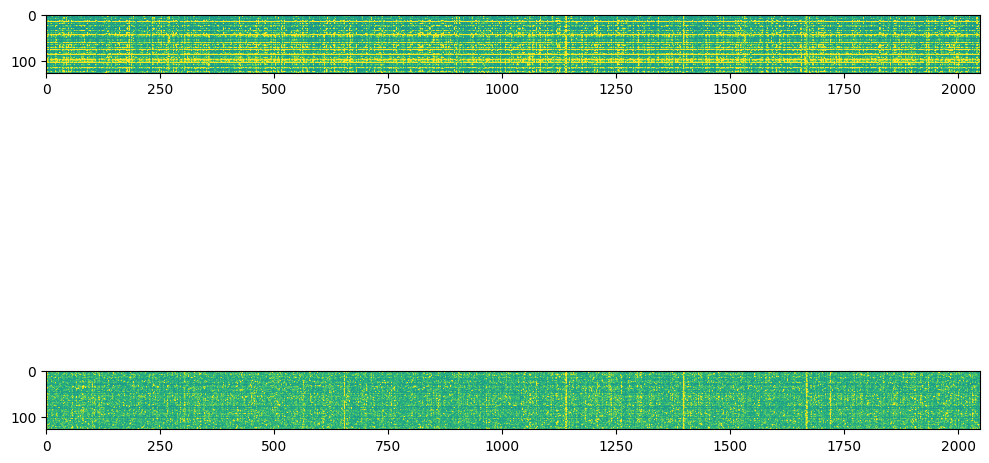

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].imshow(h.detach().numpy(), vmin=-0.5, vmax=0.5)
ax[1].imshow(h_resnet.detach().numpy(), vmin=-0.5, vmax=0.5)
fig.tight_layout()

In [89]:
h_target.std(dim=1)

tensor([0.1341, 0.1244, 0.1601, 0.1916, 0.1254, 0.1557, 0.5885, 0.1501, 0.2655,
        0.1447, 0.2308, 0.3760, 0.5198, 0.1674, 0.2709, 0.2570, 0.2212, 0.1370,
        0.2269, 0.2262, 0.2169, 0.1464, 0.1796, 0.2160, 0.2321, 0.1112, 0.1295,
        0.1739, 0.1489, 4.0113, 0.1737, 0.2053, 0.2708, 0.1494, 0.2967, 0.2244,
        0.2627, 0.1666, 0.1438, 0.1630, 0.2954, 0.2557, 0.1409, 0.1695, 0.1950,
        0.1270, 0.2158, 0.2067, 0.1902, 0.1823, 0.1838, 0.1384, 0.1323, 0.2059,
        0.1640, 0.1863, 0.2681, 0.1981, 0.1569, 0.1853, 0.2189, 0.2140, 0.1956,
        0.5140, 0.2966, 0.1820, 0.3822, 0.2000, 0.2259, 1.0141, 0.1642, 0.1945,
        0.2275, 0.1355, 0.1546, 0.2180, 0.2186, 0.3610, 0.2498, 0.2467, 0.2228,
        0.4207, 0.2602, 0.2159, 0.7793, 0.2278, 0.2354, 0.2384, 0.1750, 0.2341,
        0.1398, 0.2522, 0.1628, 0.1518, 0.1664, 0.1468, 0.4355, 0.2919, 0.1573,
        0.1881, 0.1758, 0.1586, 0.1868, 0.9462, 0.5265, 0.1755, 0.2039, 0.3576,
        0.1792, 0.1782, 0.1337, 0.1300, 

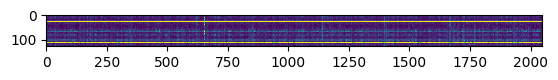

In [71]:
plt.imshow(h_target.detach().numpy(), vmin=0, vmax=1)

Epoch 0/100, Learning Rate: 0.000000
Epoch 1/100, Learning Rate: 0.000100
Epoch 2/100, Learning Rate: 0.000200
Epoch 3/100, Learning Rate: 0.000300
Epoch 4/100, Learning Rate: 0.000400
Epoch 5/100, Learning Rate: 0.000500
Epoch 6/100, Learning Rate: 0.000600
Epoch 7/100, Learning Rate: 0.000700
Epoch 8/100, Learning Rate: 0.000800
Epoch 9/100, Learning Rate: 0.000900
Epoch 10/100, Learning Rate: 0.001000
Epoch 11/100, Learning Rate: 0.001000
Epoch 12/100, Learning Rate: 0.000999
Epoch 13/100, Learning Rate: 0.000997
Epoch 14/100, Learning Rate: 0.000995
Epoch 15/100, Learning Rate: 0.000992
Epoch 16/100, Learning Rate: 0.000989
Epoch 17/100, Learning Rate: 0.000985
Epoch 18/100, Learning Rate: 0.000981
Epoch 19/100, Learning Rate: 0.000976
Epoch 20/100, Learning Rate: 0.000970
Epoch 21/100, Learning Rate: 0.000964
Epoch 22/100, Learning Rate: 0.000957
Epoch 23/100, Learning Rate: 0.000949
Epoch 24/100, Learning Rate: 0.000941
Epoch 25/100, Learning Rate: 0.000933
Epoch 26/100, Learning

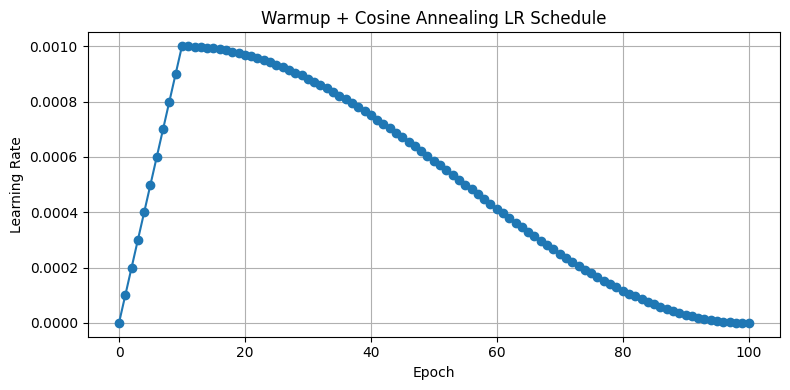

In [ ]:
import torch
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR
import matplotlib.pyplot as plt

# Dummy model and optimizer
model = nn.Linear(10, 2)
optimizer = AdamW(model.parameters(), lr=1e-3)

# Scheduler parameters
total_epochs = 100
warmup_epochs = 10
base_lr = 1e-3
min_lr = 0

# Linear warmup from 0.001 * 1e-3 = 1e-6 -> 1e-3 over `warmup_epochs`
warmup_scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: epoch / warmup_epochs if epoch < warmup_epochs else 1.0
)

# Cosine annealing from 1e-3 -> min_lr over remaining epochs
cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=total_epochs - warmup_epochs,
    eta_min=min_lr
)

# Combine schedulers
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_epochs]
)

# Track learning rates
lrs = []

for epoch in range(total_epochs + 1):
    
    # Dummy training step
    optimizer.zero_grad()
    dummy_input = torch.randn(4, 10)
    dummy_output = model(dummy_input)
    dummy_loss = dummy_output.mean()
    dummy_loss.backward()
    optimizer.step()

    # Step scheduler and record LR
    # scheduler.step()
    # lrs.append(optimizer.param_groups[0]['lr'])
    lrs.append(optimizer.param_groups[0]['lr'])
    scheduler.step()
    print(f"Epoch {epoch}/{total_epochs}, Learning Rate: {lrs[-1]:.6f}")

# Plot learning rate schedule
plt.figure(figsize=(8, 4))
plt.plot(range(total_epochs + 1), lrs, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Warmup + Cosine Annealing LR Schedule")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
from mslandcover.models import ResNetBackboneUNet
import torch
import torch.nn as nn
import torch.nn.functional as F

backbone = ResNetBackboneUNet(in_channels=3, pretrained=False)

x = torch.randn(2, 3, 256, 256)
backbone.eval()
with torch.no_grad():
    features = backbone(x)

In [4]:
for feature in features:
    print(feature.shape)

torch.Size([2, 64, 128, 128])
torch.Size([2, 256, 64, 64])
torch.Size([2, 512, 32, 32])
torch.Size([2, 1024, 16, 16])
torch.Size([2, 2048, 8, 8])


In [ ]:
class LinearProbingResNet(nn.Module):
    def __init__(self, backbone, num_classes=8):
        super(LinearProbingResNet, self).__init__()
        self.backbone = backbone
        self.classifier = nn.Conv2d(3904, num_classes, kernel_size=1, stride=1, padding=0)
        self.activation = nn.Softmax(dim=1) if num_classes > 1 else nn.Identity()

    def forward(self, x):
        input_size = x.shape[-2:]  # Store original input size
        features = self.backbone(x)
        
        # Interpolate all features to match the largest feature map size
        target_size = features[0].shape[-2:]  # Use first (largest) feature map size
        interpolated_features = [features[0]]  # First feature doesn't need interpolation
        
        for i in range(1, len(features)):
            upsampled = F.interpolate(
                features[i], 
                size=target_size, 
                mode='bilinear', 
                align_corners=False
            )
            interpolated_features.append(upsampled)
        
        # Concatenate all features
        features_concat = torch.cat(interpolated_features, dim=1)
        
        # Apply classifier
        x = self.classifier(features_concat)
        
        # Interpolate to original input size AFTER classification
        if x.shape[-2:] != input_size:
            x = F.interpolate(x, size=input_size, mode='bilinear', align_corners=False)
        
        # Apply activation last
        x = self.activation(x)
        return x


model = LinearProbingResNet(backbone, num_classes=8)
x = torch.randn(2, 3, 256, 256)
model.eval()
with torch.no_grad():
    y = model(x)
print(f"Output shape: {y.shape}")

Interpolated feature shape: torch.Size([2, 64, 128, 128])
Interpolated feature shape: torch.Size([2, 256, 128, 128])
Interpolated feature shape: torch.Size([2, 512, 128, 128])
Interpolated feature shape: torch.Size([2, 1024, 128, 128])
Interpolated feature shape: torch.Size([2, 2048, 128, 128])
Output shape: torch.Size([2, 8, 256, 256])


In [15]:
in_path = 'logs/pretrain/resnet101_20250616/byol_bands3_size256_randinitfalse/resnet101/byol/checkpoint.pth'

In [16]:
checkpoint = torch.load(in_path, map_location='cpu')

/tmp/ipykernel_222383/4051139804.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(in_path, map_location='cpu')


In [18]:
out_path = 'weights/resnet101_20250616/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth'
torch.save(checkpoint['model'], out_path)

In [35]:
import torch
import torch.nn as nn
import torchvision.models as models
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt



weights_1 = torch.load('weights/resnet101_202506/byol_bands3_size256_randinitfalse/resnet101/byol.pth', map_location='cpu')
weights_2 = torch.load('weights/resnet101_20250616/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth', map_location='cpu')
weights_3 = torch.load('weights/resnet101_20250624/byol_bands3_size256_randinitfalse/resnet101/byol_last.pth', map_location='cpu')

/tmp/ipykernel_478917/3722878223.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights_1 = torch.load('weights/resnet101_202506/byol_bands3_size256_randinitfalse/resn

In [ ]:
from tqdm import trange
batch_size = 128

model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)
model.fc = nn.Identity()  # Remove the final classification layer
model.eval()
h_inet = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part)
    h_inet.append(h_part)
h_inet = torch.cat(h_inet, dim=0)

weights_1_adj = {}
for key in list(weights_1.keys()):
    if key.startswith('online_encoder.0.'):
        new_key = key.replace('online_encoder.0.', '')
        weights_1_adj[new_key] = weights_1[key]
model.load_state_dict(weights_1_adj, strict=True)

h_1 = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part)
    h_1.append(h_part)
h_1 = torch.cat(h_1, dim=0)

weights_2_adj = {}
for key in list(weights_2.keys()):
    if key.startswith('online_encoder.0.'):
        new_key = key.replace('online_encoder.0.', '')
        weights_2_adj[new_key] = weights_2[key]
model.load_state_dict(weights_2_adj, strict=True)
h_2 = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part)
    h_2.append(h_part)
h_2 = torch.cat(h_2, dim=0)

weights_3_adj = {}
for key in list(weights_3.keys()):
    if key.startswith('online_encoder.0.'):
        new_key = key.replace('online_encoder.0.', '')
        weights_3_adj[new_key] = weights_3[key]
model.load_state_dict(weights_3_adj, strict=True)


  0%|          | 0/16 [00:10<?, ?it/s]


NameError: name 'h_3' is not defined

In [39]:
# h_3 = model(x_batch)
h_3 = []
for i in trange(0, len(x_batch), batch_size):
    x_batch_part = x_batch[i:i+batch_size]
    with torch.no_grad():
        h_part = model(x_batch_part)
    h_3.append(h_part)
h_3 = torch.cat(h_3, dim=0)

100%|██████████| 16/16 [02:43<00:00, 10.21s/it]


In [55]:
import numpy as np

def normalize_l2(x, eps=1e-8, axis=1):
    """
    Normalize a NumPy array to unit L2 norm.

    Parameters:
    x (np.ndarray): Input array.
    eps (float): Small value to avoid division by zero.


    Returns:
    np.ndarray: L2-normalized array.
    """
    return x
    # norm = np.linalg.norm(x, ord=2, axis=axis, keepdims=True)
    # return x / (norm + eps)


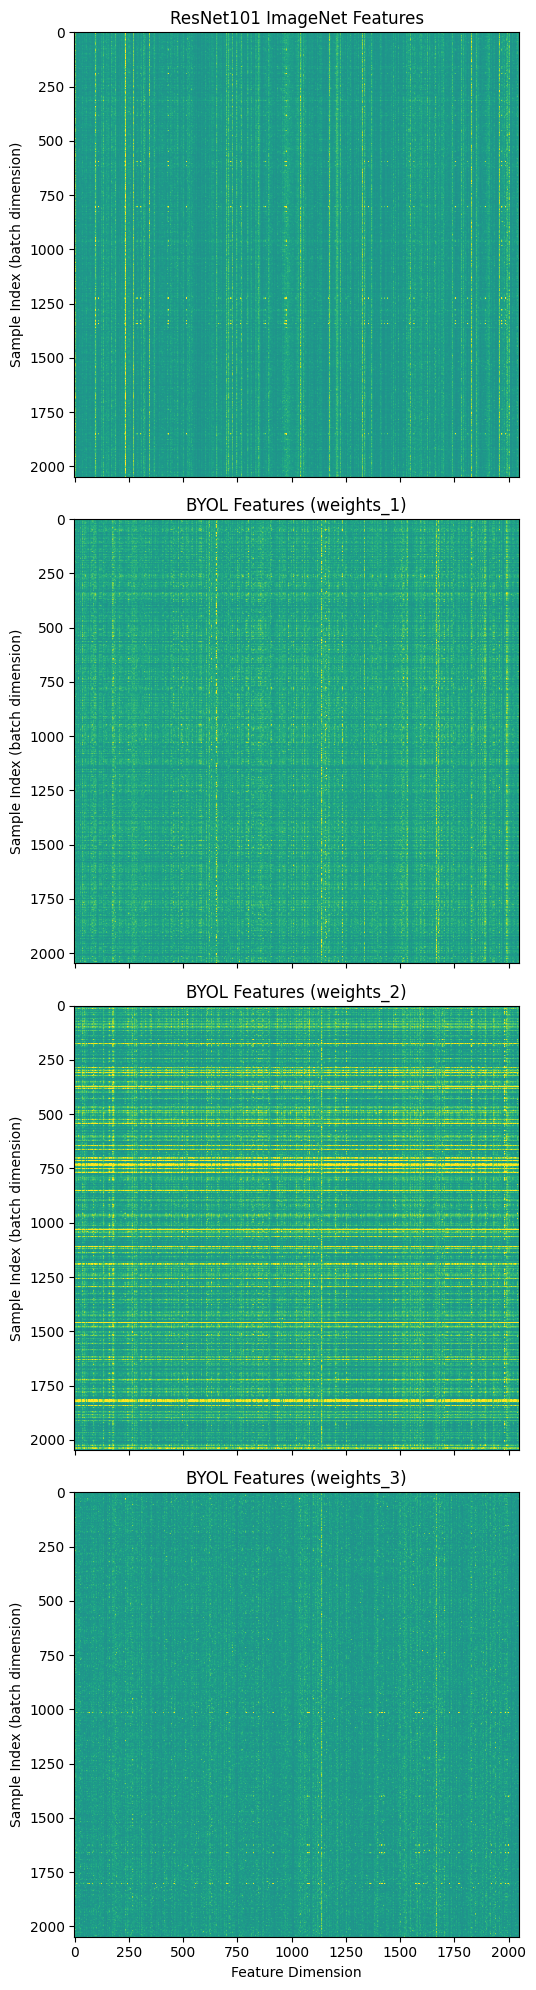

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(10, 20), sharex=True)

ax[0].imshow(normalize_l2(h_inet.detach().numpy()), vmin=h_inet.min(), vmax=h_inet.max())
ax[0].set_title('ResNet101 ImageNet Features')
ax[0].set_ylabel('Sample Index (batch dimension)')
ax[1].imshow(normalize_l2(h_1.detach().numpy()), vmin=h_inet.min(), vmax=h_inet.max())
ax[1].set_title('BYOL Features (weights_1)')
ax[1].set_ylabel('Sample Index (batch dimension)')
ax[2].imshow(normalize_l2(h_2.detach().numpy()), vmin=h_inet.min(), vmax=h_inet.max())
ax[2].set_title('BYOL Features (weights_2)')
ax[2].set_ylabel('Sample Index (batch dimension)')
ax[3].imshow(normalize_l2(h_3.detach().numpy()), vmin=h_inet.min(), vmax=h_inet.max())
ax[3].set_title('BYOL Features (weights_3)')
ax[3].set_ylabel('Sample Index (batch dimension)')
ax[3].set_xlabel('Feature Dimension')
fig.tight_layout()
plt.show()

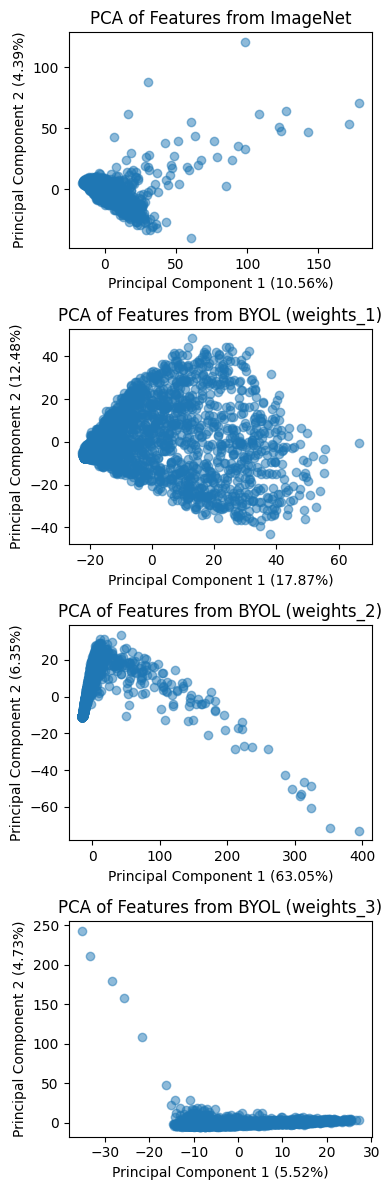

In [60]:
# view principal components of features
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

fig, ax = plt.subplots(4, 1, figsize=(4, 12))

feature_models = ['ImageNet', 'BYOL (weights_1)', 'BYOL (weights_2)', 'BYOL (weights_3)']

for i, embeddings in enumerate([h_inet, h_1, h_2, h_3]):
    # Flatten the embeddings
    # flattened_embeddings = embeddings.view(embeddings.size(0), -1).detach().numpy()
    
    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=2)
    )
    pca_embeddings = pipe.fit_transform(embeddings.detach().numpy())
    
    # Plot the PCA results
    ax[i].scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], alpha=0.5)
    ax[i].set_title(f'PCA of Features from {feature_models[i]}')
    ax[i].set_xlabel(f'Principal Component 1 ({pipe['pca'].explained_variance_ratio_[0]:.2%})')
    ax[i].set_ylabel(f'Principal Component 2 ({pipe['pca'].explained_variance_ratio_[1]:.2%})')

fig.tight_layout()
plt.show()

In [63]:
print(f'H_inet std: {h_inet.std(dim=0).mean().item()}')
print(f'H_1 std: {h_1.std(dim=0).mean().item()}')
print(f'H_2 std: {h_2.std(dim=0).mean().item()}')
print(f'H_3 std: {h_3.std(dim=0).mean().item()}')

H_inet std: 0.2012365758419037
H_1 std: 0.34965798258781433
H_2 std: 0.6992865800857544
H_3 std: 0.29953163862228394
